In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os
import glob
import country_converter as coco
import pyreadr
import time
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## R Code first part (Legacy — Not required for experiment)

> The cells in this section replicate the R data-loading logic in Python. They are kept for reference / traceability with the original R pipeline but are **not required** to produce the experiment's results. Skip this section when running the notebook end-to-end.

In [2]:
# LEGACY — Not required for experiment
path = f"HLD/Mx_1x1"
result = pyreadr.read_r('full_simulation_results8.rds')
full_results = list(result.values())[0]

In [3]:
# LEGACY — Not required for experiment
# Get list of all Mx_1x1.txt files
files = glob.glob(os.path.join(path, "*.Mx_1x1.txt"))

def read_country_file(file_path):
    """Read each country mortality file and add ISO code"""
    try:
        # Extract ISO code from filename
        ISO = os.path.basename(file_path).split('.')[0]
        
        # Read all lines
        with open(file_path, 'r', encoding='utf-8') as f:
            lines = f.readlines()
        
        # Find the line that starts with "Year" (this is our header)
        header_row = None
        for i, line in enumerate(lines):
            if line.strip().startswith('Year') and 'Age' in line:
                header_row = i
                break
        
        if header_row is None:
            print(f"Warning: No header found in file: {file_path}")
            return None
        
        # Get the data rows
        data_lines = lines[header_row:]
        
        # Create a temporary file content
        temp_content = ''.join(data_lines)
        
        # Read into DataFrame
        from io import StringIO
        df = pd.read_csv(StringIO(temp_content), sep=r'\s+', engine='python')
        
        # Clean column names
        df.columns = ["Year", "Age", "Female", "Male", "Total"]
        
        # Add ISO column
        df['ISO'] = ISO
        
        # Convert columns to appropriate types
        df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
        df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
        df['Female'] = pd.to_numeric(df['Female'], errors='coerce')
        df['Male'] = pd.to_numeric(df['Male'], errors='coerce')
        df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
        
        return df
        
    except Exception as e:
        print(f"Error processing file: {file_path}\nError: {e}")
        return None

mortality_dfs = []
for file in files:
    result = read_country_file(file)
    if result is not None:
        mortality_dfs.append(result)
mortality_df = pd.concat(mortality_dfs, ignore_index=True)

# display(mortality_df)

# Keep only rows from each country's most recent year (pandas 3.0 compatible)
max_years = mortality_df.groupby('ISO')['Year'].transform('max')
mortality_df_transformed = (mortality_df[mortality_df['Year'] == max_years]
                           .reset_index(drop=True)
                           .melt(id_vars=['ISO', 'Year', 'Age'], 
                                 value_vars=['Female', 'Male'],
                                 var_name='Sex', 
                                 value_name='mortality_rate')
                           .assign(Sex=lambda x: x['Sex'].map({'Female': 'Women', 'Male': 'Men'}))
                           [['ISO', 'Age', 'Sex', 'mortality_rate', 'Year']])
# display(mortality_df_transformed)
# Some mortality data is available for countries with territorial issues
# Keep only rows for total populations
mortality2 = mortality_df_transformed[
    ~mortality_df_transformed['ISO'].isin([
        "FRACNP", "NZL_MA", "NZL_NM", "DEUTE", "DEUTW", 
        "GBRTENW", "GBRCENW", "GBR_SCO", "GBR_NIR"
    ])
].copy()

# Keep only the first 3 letters in ISO
mortality2['ISO'] = mortality2['ISO'].str[:3]
mortality2

# Print summary of the transformed data
print(f"Number of countries: {mortality_df_transformed['ISO'].nunique()}")
print(f"Year range: {mortality_df_transformed['Year'].min()} to {mortality_df_transformed['Year'].max()}")
display(mortality_df_transformed.head())

Number of countries: 50
Year range: 2008 to 2023


,ISO,Age,Sex,mortality_rate,Year
0,AUS,0.0,Women,0.003100,2021
1,AUS,1.0,Women,0.000166,2021
2,AUS,2.0,Women,0.000110,2021
3,AUS,3.0,Women,0.000081,2021
4,AUS,4.0,Women,0.000073,2021


In [4]:
# LEGACY — Not required for experiment
# Join with demographic data
final_df = full_results.merge(
    mortality2,
    left_on=['ISO', 'age', 'Sex'],
    right_on=['ISO', 'Age', 'Sex'],
    how='left'
)

# Check for any missing matches
missing_matches = (final_df[final_df['mortality_rate'].isna()]
                  [['ISO', 'age', 'Sex']]
                  .drop_duplicates()
                  .sort_values(['ISO', 'age', 'Sex']))

# Print summary of the final joined data
print(f"Final dataset summary:")
print(f"Total rows: {len(final_df)}")
print(f"Countries with missing mortality data:")
print(missing_matches['ISO'].unique())

Final dataset summary:
Total rows: 1890000
Countries with missing mortality data:
<StringArray>
['AND', 'ARE', 'ASM', 'ATG', 'BHR', 'BHS', 'BMU', 'BRB', 'BRN', 'CYP', 'GRL',
 'GUY', 'KNA', 'KWT', 'MLT', 'NRU', 'OMN', 'PAN', 'PRI', 'PYF', 'QAT', 'ROU',
 'SAU', 'SGP', 'SYC', 'TTO', 'URY']
Length: 27, dtype: str


In [5]:
# LEGACY — Not required for experiment
countries_in_data = final_df['ISO'].unique()

country_info = pd.DataFrame({
    'ISO': countries_in_data,
    'region': coco.convert(countries_in_data, to='UNregion'),
    'continent': coco.convert(countries_in_data, to='continent')
}).dropna()

# Get list of missing countries and their regions
missing_countries = missing_matches['ISO'].unique()
missing_regions = country_info[country_info['ISO'].isin(missing_countries)]['region'].unique()

# Create regional medians for imputation
regional_backup = (final_df[~final_df['mortality_rate'].isna()]
                  .merge(country_info[['ISO', 'region']], on='ISO')
                  .query('region in @missing_regions')
                  .groupby(['region', 'age', 'Sex'])
                  ['mortality_rate']
                  .median()
                  .reset_index()
                  .rename(columns={'mortality_rate': 'mortality_rate_region'}))

# Apply imputations
final_df_imputed = (final_df
                   .merge(country_info[['ISO', 'region']], on='ISO', how='left')
                   .merge(regional_backup, on=['region', 'age', 'Sex'], how='left')
                   .assign(mortality_rate=lambda x: x['mortality_rate'].fillna(x['mortality_rate_region']))
                   .drop(columns=['mortality_rate_region', 'region']))

# Handle remaining missing values with global medians by age and sex
global_medians = (final_df_imputed[~final_df_imputed['mortality_rate'].isna()]
                 .groupby(['age', 'Sex'])
                 ['mortality_rate']
                 .median()
                 .reset_index()
                 .rename(columns={'mortality_rate': 'global_median'}))

final_df_imputed = (final_df_imputed
                   .merge(global_medians, on=['age', 'Sex'], how='left')
                   .assign(mortality_rate=lambda x: x['mortality_rate'].fillna(x['global_median']))
                   .drop(columns=['global_median']))

# Some countries have mortality rates for some ages at 0
# Set to a bare minimum of 1/100,000 instead
final_df_imputed.loc[final_df_imputed['mortality_rate'] == 0, 'mortality_rate'] = 0.00001

# Print validation
print(f"Total missing values before imputation: {final_df['mortality_rate'].isna().sum()}")
print(f"Total missing values after imputation: {final_df_imputed['mortality_rate'].isna().sum()}")

# Save results (equivalent to saveRDS)
final_df_imputed.to_pickle("final_df_imputed.pkl")

print(final_df_imputed.dtypes)


Total missing values before imputation: 810000
Total missing values after imputation: 0
bmi                        float64
height                     float64
weight                     float64
age                        float64
pal                        float64
bmr                        float64
eer                        float64
diabetes                     int32
diabetes_prob              float64
Age_Group                      str
Sex                            str
ISO                            str
Population                 float64
weighting                  float64
diabetes_type              float64
scenario                       str
qualifies_for_treatment       bool
adheres_to_treatment          bool
individual_effect          float64
treatment_weight           float64
treatment_bmr              float64
treatment_eer              float64
weight_diff                float64
eer_diff                   float64
new_bmi                    float64
Age                        float64
mo

## Importing Data and imputing missing values in the mortality table

In [6]:
def impute_missing_mortality(mortality_df, simulation_df):
    """
    Replicates seth's R logic to fill missing mortality data:
    1. Identifies countries in simulation_df that are missing from mortality_df
    2. Calculates Median Mortality by [Region, Age, Sex]
    3. Imputes missing countries using their Region's median rates
    4. Falls back to Global Median if region is unavailable
    5. Sets a minimum floor for mortality rates to avoid zeros
    """
    
    # --- 1. Preparation ---
    # Create working copy
    df = mortality_df.copy()
    
    # Get list of countries that need data
    target_isos = simulation_df['ISO'].unique()
    existing_isos = df['ISO'].unique()
    missing_isos = list(set(target_isos) - set(existing_isos))
    
    print(f"Found {len(missing_isos)} countries requiring imputation: {missing_isos}")
    
    # Map ISOs to UN Regions
    cc = coco.CountryConverter()
    # We assign regions to the existing mortality data to calculate averages
    iso_region_map = cc.convert(names=df['ISO'].unique(), to='UNregion', not_found='World')
    iso_dict = dict(zip(df['ISO'].unique(), iso_region_map))
    df['region'] = df['ISO'].map(iso_dict)

    # --- 2. Calculate Averages (The "Model") ---
    
    # Calculate Regional Medians: Group by [Region, Age, Sex]
    regional_medians = df.groupby(['region', 'Age', 'Sex'])['mortality_rate'].median().reset_index()
    
    # Calculate Global Medians: Group by [Age, Sex] (Fallback)
    global_medians = df.groupby(['Age', 'Sex'])['mortality_rate'].median().reset_index()

    # --- 3. Imputation Loop ---
    
    new_data_frames = []
    
    for iso in missing_isos:
        # Identify the region for the missing country
        region = cc.convert(names=iso, to='UNregion', not_found='World')
        
        # Try to get data for that specific region
        imputed_data = regional_medians[regional_medians['region'] == region].copy()
        
        # If that region doesn't exist in our data, use Global Median
        if imputed_data.empty:
            imputed_data = global_medians.copy()
        
        # Assign the current ISO to this new data chunk
        imputed_data['ISO'] = iso
        
        # Keep only necessary columns
        if 'region' in imputed_data.columns:
            imputed_data = imputed_data.drop(columns=['region'])
            
        new_data_frames.append(imputed_data)

    # --- 4. Merge and Final Cleanup ---
    
    # Combine original data with new imputed rows
    if new_data_frames:
        df_imputed = pd.concat([mortality_df, pd.concat(new_data_frames)], ignore_index=True)
    else:
        df_imputed = mortality_df.copy()
        
    # Apply R Logic: "Set to a bare minimum of 1/100,000 instead of 0"
    df_imputed.loc[df_imputed['mortality_rate'] <= 0, 'mortality_rate'] = 0.00001
    
    return df_imputed


# Load the raw simulation data
# result_imputed_raw = pyreadr.read_r('final_df_imputed.rds')
result_imputed_raw = pyreadr.read_r('full_simulation_results8.rds')
final_df_imputed = list(result_imputed_raw.values())[0].copy()

# Load teh mortality data
result_mortality_raw = pyreadr.read_r('mortality2.rds') 
mortality2_raw = list(result_mortality_raw.values())[0].copy()

# fill in the missing value through the impute_missing_mortality function which uses median
mortality2 = impute_missing_mortality(mortality2_raw, final_df_imputed) # This function is specifically imputing values into the mortality table

Found 27 countries requiring imputation: ['CYP', 'ARE', 'MLT', 'TTO', 'SGP', 'ROU', 'GUY', 'PRI', 'KNA', 'AND', 'BHR', 'PYF', 'ATG', 'KWT', 'URY', 'BRB', 'SAU', 'BMU', 'QAT', 'NRU', 'SYC', 'ASM', 'BRN', 'GRL', 'PAN', 'BHS', 'OMN']


In [7]:
# =====================================================for debugging=====================================================
mortality_df = mortality2_raw.copy()
simulation_df = final_df_imputed.copy()

df = mortality2_raw.copy()
# Get list of countries that need data
target_isos = simulation_df['ISO'].unique()
existing_isos = df['ISO'].unique()
missing_isos = list(set(target_isos) - set(existing_isos))

print(f"Found {len(missing_isos)} countries requiring imputation: {missing_isos}")

# Map ISOs to UN Regions
cc = coco.CountryConverter()
# We assign regions to the existing mortality data to calculate averages
iso_region_map = cc.convert(names=df['ISO'].unique(), to='UNregion', not_found='World')
iso_dict = dict(zip(df['ISO'].unique(), iso_region_map))
df['region'] = df['ISO'].map(iso_dict)

# --- 2. Calculate Averages (The "Model") ---

# Calculate Regional Medians: Group by [Region, Age, Sex]
regional_medians = df.groupby(['region', 'Age', 'Sex'])['mortality_rate'].median().reset_index()

# Calculate Global Medians: Group by [Age, Sex] (Fallback)
global_medians = df.groupby(['Age', 'Sex'])['mortality_rate'].median().reset_index()

# --- 3. Imputation Loop ---

new_data_frames = []

for iso in missing_isos:
    # Identify the region for the missing country
    region = cc.convert(names=iso, to='UNregion', not_found='World')
    
    # Try to get data for that specific region
    imputed_data = regional_medians[regional_medians['region'] == region].copy()
    
    # If that region doesn't exist in our data, use Global Median
    if imputed_data.empty:
        imputed_data = global_medians.copy()
    
    # Assign the current ISO to this new data chunk
    imputed_data['ISO'] = iso
    
    # Keep only necessary columns
    if 'region' in imputed_data.columns:
        imputed_data = imputed_data.drop(columns=['region'])
        
    new_data_frames.append(imputed_data)

# --- 4. Merge and Final Cleanup ---

# Combine original data with new imputed rows
if new_data_frames:
    df_imputed = pd.concat([mortality_df, pd.concat(new_data_frames)], ignore_index=True)
else:
    df_imputed = mortality_df.copy()
    
# Apply R Logic: "Set to a bare minimum of 1/100,000 instead of 0"
df_imputed.loc[df_imputed['mortality_rate'] <= 0, 'mortality_rate'] = 0.00001

Found 27 countries requiring imputation: ['CYP', 'ARE', 'MLT', 'TTO', 'SGP', 'ROU', 'GUY', 'PRI', 'KNA', 'AND', 'BHR', 'PYF', 'ATG', 'KWT', 'URY', 'BRB', 'SAU', 'BMU', 'QAT', 'NRU', 'SYC', 'ASM', 'BRN', 'GRL', 'PAN', 'BHS', 'OMN']


## Simulation

In [8]:
# Not sure why I put this here...
if 'Year' in final_df_imputed.columns:
    final_df_imputed = final_df_imputed.drop(columns=['Year'])

# ========================== was there in the R code. Not sure why this is needed as teh age range only goes up to 89 years==========================
final_df_imputed = pd.merge(final_df_imputed,
    mortality2.set_index(['ISO', 'Age', 'Sex'])['mortality_rate'], 
    left_on=['ISO', 'age', 'Sex'], 
    right_index=True, 
    how='left',
    suffixes=('_x', '_y')
)
# Coalesce mortality rates
if 'mortality_rate_x' in final_df_imputed.columns:
    final_df_imputed['mortality_rate'] = final_df_imputed['mortality_rate_x'].fillna(final_df_imputed['mortality_rate_y'])
    final_df_imputed = final_df_imputed.drop(columns=['mortality_rate_x', 'mortality_rate_y'])

# =========================================================================================================================
final_df_imputed

,bmi,height,weight,age,pal,bmr,eer,diabetes,diabetes_prob,Age_Group,...,qualifies_for_treatment,adheres_to_treatment,individual_effect,treatment_weight,treatment_bmr,treatment_eer,weight_diff,eer_diff,new_bmi,mortality_rate
0,31.732335,167.256031,88.769874,18.0,1.907613,1682.048935,3208.698122,0,0.049587,18-19,...,True,True,0.133005,76.963013,1563.980322,2983.468922,11.806861,225.229200,27.511767,0.000219
1,22.837877,170.271947,66.212797,19.0,1.668370,1470.327641,2453.050012,0,0.019498,18-19,...,False,False,0.000000,66.212797,1470.327641,2453.050012,0.000000,0.000000,22.837877,0.000223
2,24.279639,166.741705,67.504186,19.0,1.598766,1461.177520,2336.080329,0,0.022683,18-19,...,False,False,0.000000,67.504186,1461.177520,2336.080329,0.000000,0.000000,24.279639,0.000223
3,24.629954,168.994006,70.340623,19.0,1.636463,1503.618767,2460.615741,0,0.023532,18-19,...,False,False,0.000000,70.340623,1503.618767,2460.615741,0.000000,0.000000,24.629954,0.000223
4,41.914327,176.560336,130.661848,18.0,2.025949,2159.120582,4374.267845,0,0.144356,18-19,...,True,True,0.131230,113.515105,1987.653154,4026.883607,17.146743,347.384237,36.413914,0.000219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889995,32.953709,177.170502,103.439673,87.0,1.626660,1711.712367,2784.373891,0,0.417004,85plus,...,False,False,0.000000,103.439673,1711.712367,2784.373891,0.000000,0.000000,32.953709,0.129026
1889996,32.715557,175.118746,100.327409,88.0,1.677762,1662.766247,2789.725766,0,0.406036,85plus,...,False,False,0.000000,100.327409,1662.766247,2789.725766,0.000000,0.000000,32.715557,0.147341
1889997,46.917129,170.124381,135.788984,85.0,1.562331,2001.167222,3126.486237,1,1.000000,85plus,...,False,False,0.000000,135.788984,2001.167222,3126.486237,0.000000,0.000000,46.917129,0.109877
1889998,28.346446,179.195772,91.023624,86.0,2.247202,1605.209815,3607.231207,1,0.248996,85plus,...,False,False,0.000000,91.023624,1605.209815,3607.231207,0.000000,0.000000,28.346446,0.113183


In [9]:
# Assign hazard rates from hard coded values
def get_raw_bmi_hazard_ratio(bmi):
    # takes in series and maps the relevant hazard ratio as per below conditions
    """Get raw BMI hazard ratios from literature"""
    return np.where(bmi < 18.5, 1.51,
           np.where((bmi >= 18.5) & (bmi < 20.0), 1.13,
           np.where((bmi >= 20.0) & (bmi < 25.0), 1.00,  # Reference group
           np.where((bmi >= 25.0) & (bmi < 27.5), 1.07,
           np.where((bmi >= 27.5) & (bmi < 30.0), 1.20,
           np.where((bmi >= 30.0) & (bmi < 35.0), 1.45,
           np.where((bmi >= 35.0) & (bmi < 40.0), 1.94,
           np.where(bmi >= 40.0, 2.76, 
                    np.nan))))))))

final_df_imputed['baseline_bmi_hr'] = get_raw_bmi_hazard_ratio(final_df_imputed['bmi']) # categorizing the baseline bmi
final_df_imputed['semaglutide_bmi_hr'] = get_raw_bmi_hazard_ratio(final_df_imputed['new_bmi']) # categorizing the semaglutide bmi
final_df_imputed["hr_conversion_factor(%)"] = (final_df_imputed["semaglutide_bmi_hr"]/final_df_imputed["baseline_bmi_hr"]) - 1 # hazard ratio of old vs new BMIs needs to be normalized to the 20-25 range values. the new mortality can just be multiplied by this value

final_df_imputed

,bmi,height,weight,age,pal,bmr,eer,diabetes,diabetes_prob,Age_Group,...,treatment_weight,treatment_bmr,treatment_eer,weight_diff,eer_diff,new_bmi,mortality_rate,baseline_bmi_hr,semaglutide_bmi_hr,hr_conversion_factor(%)
0,31.732335,167.256031,88.769874,18.0,1.907613,1682.048935,3208.698122,0,0.049587,18-19,...,76.963013,1563.980322,2983.468922,11.806861,225.229200,27.511767,0.000219,1.45,1.20,-0.172414
1,22.837877,170.271947,66.212797,19.0,1.668370,1470.327641,2453.050012,0,0.019498,18-19,...,66.212797,1470.327641,2453.050012,0.000000,0.000000,22.837877,0.000223,1.00,1.00,0.000000
2,24.279639,166.741705,67.504186,19.0,1.598766,1461.177520,2336.080329,0,0.022683,18-19,...,67.504186,1461.177520,2336.080329,0.000000,0.000000,24.279639,0.000223,1.00,1.00,0.000000
3,24.629954,168.994006,70.340623,19.0,1.636463,1503.618767,2460.615741,0,0.023532,18-19,...,70.340623,1503.618767,2460.615741,0.000000,0.000000,24.629954,0.000223,1.00,1.00,0.000000
4,41.914327,176.560336,130.661848,18.0,2.025949,2159.120582,4374.267845,0,0.144356,18-19,...,113.515105,1987.653154,4026.883607,17.146743,347.384237,36.413914,0.000219,2.76,1.94,-0.297101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889995,32.953709,177.170502,103.439673,87.0,1.626660,1711.712367,2784.373891,0,0.417004,85plus,...,103.439673,1711.712367,2784.373891,0.000000,0.000000,32.953709,0.129026,1.45,1.45,0.000000
1889996,32.715557,175.118746,100.327409,88.0,1.677762,1662.766247,2789.725766,0,0.406036,85plus,...,100.327409,1662.766247,2789.725766,0.000000,0.000000,32.715557,0.147341,1.45,1.45,0.000000
1889997,46.917129,170.124381,135.788984,85.0,1.562331,2001.167222,3126.486237,1,1.000000,85plus,...,135.788984,2001.167222,3126.486237,0.000000,0.000000,46.917129,0.109877,2.76,2.76,0.000000
1889998,28.346446,179.195772,91.023624,86.0,2.247202,1605.209815,3607.231207,1,0.248996,85plus,...,91.023624,1605.209815,3607.231207,0.000000,0.000000,28.346446,0.113183,1.20,1.20,0.000000


In [10]:
def run_multi_simulation(df_input, mortality_lookup, n_iterations=100, benefit_reduction=0.5,seed=42):
    # Runs the mortality simulation N times and returns the average impact. This is a more computationally 
    # efficient version of the one written in the Mortaility Results testing section.
    np.random.seed(seed)
    
    # Create a template for accumulating results
    # We group by ISO and scenario to keep the structure consistent
    total_results = None
    
    # Pre-select only the columns we need for the actual simulation to save memory
    col_list = ["age", "Sex", "ISO", "scenario", "weighting", "hr_conversion_factor(%)"]
    base_sim = df_input[col_list].copy()
    row_num = len(base_sim) # used to generate the random numbers
    
    print(f"Starting {n_iterations} iterations...")

    for i in range(n_iterations):
        # Local copy for this specific iteration
        current_sim = base_sim.copy()
        current_sim["bl_alive"] = 1.0
        current_sim["sg_alive"] = 1.0
        
        # We'll store the 'diff' for each year in this iteration
        iter_diffs = pd.DataFrame(index=current_sim.index)
        iter_diffs["diff_Y0"] = 0

        for year in range(1, 11):
            current_age = current_sim["age"] + year
            
            # Merge mortality rates for the current age
            # Note: Using a left merge on the specific year
            temp_mort = pd.merge(
                current_sim[['ISO', 'Sex']].assign(current_age=current_age),
                mortality_lookup.set_index(['ISO', 'Age', 'Sex'])['mortality_rate'],
                left_on=['ISO', 'current_age', 'Sex'],
                right_index=True,
                how='left'
            )['mortality_rate'].fillna(0) # Fallback for missing age data

            # Calculate Semaglutide Mortality Rate
            # Full benefit if < 75, half benefit if >= 75
            benefit_mask = current_age < 75
            sg_MR = np.where(
                benefit_mask,
                temp_mort * (1 + current_sim["hr_conversion_factor(%)"]),
                temp_mort * (1 + (current_sim["hr_conversion_factor(%)"] * benefit_reduction))
            )

            # Generate random numbers for the entire population
            rand = np.random.rand(row_num)

            # Update survival status: Only those currently alive can die
            # A person dies if their specific Mortality Rate is greater than the random draw
            current_sim.loc[(current_sim["bl_alive"] == 1) & (temp_mort > rand), "bl_alive"] = 0
            current_sim.loc[(current_sim["sg_alive"] == 1) & (sg_MR > rand), "sg_alive"] = 0
            
            # Record the difference in survival for this year
            iter_diffs[f"diff_Y{year}"] = current_sim["sg_alive"] - current_sim["bl_alive"]

        # Weight the differences and group by ISO/Scenario
        iter_diffs[['ISO', 'scenario']] = current_sim[['ISO', 'scenario']]
        iter_summary = iter_diffs.groupby(['ISO', 'scenario']).sum()
        
        # Accumulate
        if total_results is None:
            total_results = iter_summary
        else:
            total_results = total_results.add(iter_summary)

        # Progress tracker
        if (i + 1) % 10 == 0:
            print(f"Completed {i + 1}/{n_iterations} iterations")

    # Average the results
    avg_results = total_results / n_iterations
    
    # Calculate the total person-years saved (the sum of diffs across all years)
    avg_results["total_person_years_saved"] = avg_results.sum(axis=1)
    
    return avg_results

# Execution
final_output = run_multi_simulation(final_df_imputed, mortality2, n_iterations=10)

final_output.sort_values("total_person_years_saved", ascending=False)

Starting 10 iterations...
Completed 10/10 iterations


,,diff_Y0,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,total_person_years_saved
ISO,scenario,,,,,,,,,,,,
HUN,max_uptake,0.0,11.3,22.4,31.8,41.0,49.7,59.7,69.4,77.5,86.9,95.2,544.9
ROU,max_uptake,0.0,11.9,21.1,30.2,39.0,48.9,59.2,66.6,75.4,83.6,95.0,530.9
LTU,max_uptake,0.0,9.1,17.9,25.7,32.8,43.3,52.2,59.0,65.1,75.1,80.9,461.1
HRV,max_uptake,0.0,7.1,15.6,25.3,31.0,39.5,47.2,55.1,62.4,69.1,76.8,429.1
LVA,max_uptake,0.0,9.0,16.4,24.0,33.1,38.8,46.7,54.2,60.2,66.1,72.6,421.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHE,mod_uptake,0.0,1.4,2.1,2.9,3.7,4.4,4.7,5.7,7.1,7.7,8.3,48.0
KOR,max_uptake,0.0,0.9,1.4,2.2,3.2,3.9,4.6,5.5,6.4,7.8,8.8,44.7
JPN,max_uptake,0.0,0.6,1.2,1.5,2.1,3.2,4.0,5.4,7.0,7.7,8.8,41.5


#### Adding the carbon emissions per capita

In [11]:
emissions_raw = pd.read_excel("API_EN.GHG.CO2.PC.CE.AR5_DS2_en_excel_v2_3736.xls",skiprows=3)
# emissions = emissions_raw[["Country Name","Country Code","2020"]].copy()

# Get the year columns
year_columns = [col for col in emissions_raw.columns if col.isdigit()]
year_columns = sorted(year_columns, reverse=True)  # Start from most recent year

# Function to get latest non-null value
def get_latest_emissions(row):
    for year in year_columns:
        if pd.notna(row[year]):
            return row[year]
    return None

# Create the mapping table
emissions_mapping = emissions_raw[['Country Name', 'Country Code']].copy()
emissions_mapping['per_capita_emissions tCO2e'] = emissions_raw.apply(get_latest_emissions, axis=1)
emissions_mapping

,Country Name,Country Code,per_capita_emissions tCO2e
0,Aruba,ABW,4.936708
1,Africa Eastern and Southern,AFE,0.784641
2,Afghanistan,AFG,0.210043
3,Africa Western and Central,AFW,0.482217
4,Angola,AGO,0.768163
...,...,...,...
261,Kosovo,XKX,NaN
262,"Yemen, Rep.",YEM,0.276684
263,South Africa,ZAF,6.286316
264,Zambia,ZMB,0.388873


In [12]:
final = pd.merge(final_output.reset_index(),emissions_mapping.set_index("Country Code")['per_capita_emissions tCO2e'],how="left",left_on="ISO",right_index=True)

# just to make the loops later easier 
final.rename(columns={"per_capita_emissions tCO2e":"emissions_factor_Y0"},inplace=True)
final[f"total_emissions"] = 0

# Computing total emissions by looping through each year. the emsisions are expected to drop by 1% each year
for year in range(10):
    final[f"emissions_factor_Y{year+1}"] = final[f"emissions_factor_Y{year}"] * 0.99
    final[f"emissions_Y{year+1}"] = final[f"diff_Y{year+1}"] * final[f"emissions_factor_Y{year+1}"]
    final[f"total_emissions"] = final[f"total_emissions"] + final[f"emissions_Y{year+1}"]
    
final.sort_values("total_emissions",ascending=False)

,ISO,scenario,diff_Y0,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,...,emissions_factor_Y6,emissions_Y6,emissions_factor_Y7,emissions_Y7,emissions_factor_Y8,emissions_Y8,emissions_factor_Y9,emissions_Y9,emissions_factor_Y10,emissions_Y10
102,QAT,max_uptake,0.0,4.9,8.7,13.8,17.0,24.0,30.1,37.0,...,45.339344,1364.714258,44.885951,1660.780175,44.437091,1848.582992,43.992720,2080.855668,43.552793,2308.298031
103,QAT,mod_uptake,0.0,2.0,4.4,7.2,9.7,12.4,15.0,18.7,...,45.339344,680.090162,44.885951,839.367277,44.437091,973.172296,43.992720,1086.620190,43.552793,1180.280691
72,KWT,max_uptake,0.0,4.9,11.1,15.7,19.0,23.8,28.9,34.4,...,21.654982,625.828989,21.438432,737.482078,21.224048,868.063570,21.011808,970.745515,20.801690,1085.848197
124,USA,max_uptake,0.0,7.4,13.9,21.8,27.9,36.4,44.1,53.0,...,13.087784,577.171268,12.956906,686.716019,12.827337,774.771152,12.699064,874.965481,12.572073,954.220337
14,BHR,max_uptake,0.0,4.7,8.3,13.4,17.2,20.0,23.8,28.2,...,22.342512,531.751783,22.119087,623.758247,21.897896,720.440776,21.678917,819.463061,21.462128,937.894984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,NRU,mod_uptake,0.0,4.0,7.9,12.4,15.8,20.5,24.6,29.3,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0,AND,max_uptake,0.0,2.7,6.0,9.1,13.5,16.7,21.4,23.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AND,mod_uptake,0.0,1.6,4.1,5.9,7.8,9.4,10.6,12.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,TWN,max_uptake,0.0,2.2,3.6,4.6,5.6,6.8,9.0,11.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
final.sort_values("total_emissions",ascending=False).to_csv("mortality model total emissions.csv",index=False)

#### Mortaility Results testing

> The author flagged this section as "(not required)" for the headline result (`final_output`), which comes from `run_multi_simulation()`. **However**, the Plots section below depends on the rich `simulation_result` produced here (it has `Age_Group`, `bl_alive_*`, `sg_alive_*` columns that `final_output` lacks). So:
> - **Skip if** you only need the aggregated `final_output` and emissions calculations.
> - **Run if** you want the per-country / per-age-group plots in the Plots section.
>
> Inspection-only cells inside this section are marked `# LEGACY — Not required for experiment`.

In [14]:
# NEEDED if you plan to run the Plots section below (provides the rich simulation_result)
# sets up 1 rung of the simulation. TO be used for testing and checking the logic
col_list = ["age","Age_Group","Sex","ISO","scenario","weighting","hr_conversion_factor(%)","baseline_bmi_hr","semaglutide_bmi_hr"] # selecting only cols needed for trh simulation
benefit_reduction = 0.5 # reduced benefit for ppl who started less than 75 but aged beyond 75 as the years accrued
simulation_result = final_df_imputed[col_list].copy()

# initializing age and alive statuses 
simulation_result["current_age"] = simulation_result["age"].copy()
simulation_result["bl_alive_Y0"] = 1 
simulation_result["sg_alive_Y0"] = 1
simulation_result["diff_Y0"] = 0

row_num = len(simulation_result) # number of rows tells us how many random numbers are needed to be generated

for year in range(1,11):
    simulation_result["current_age"] = simulation_result["age"] + year

    simulation_result = pd.merge(simulation_result,
                                mortality2.set_index(['ISO', 'Age', 'Sex'])['mortality_rate'], 
                                left_on=['ISO', 'current_age', 'Sex'], 
                                right_index=True, 
                                how='left').rename(columns={"mortality_rate":f"bl_MR_Y{year}"})
     
    # Since anyone over the age of 75 is not prescribed ozempic as per our assumption, we'll make assumption that anyone who
    # started off less than 75 but turned 75 and obove as they age in the in mortality model will only gain half the benfit
    simulation_result.loc[simulation_result["current_age"] < 75,f"sg_MR_Y{year}"] = simulation_result[f"bl_MR_Y{year}"] * (1 + simulation_result["hr_conversion_factor(%)"]) # these ppl get the full benefit
    simulation_result.loc[simulation_result["current_age"] >= 75,f"sg_MR_Y{year}"] = simulation_result[f"bl_MR_Y{year}"] * (1 + (simulation_result["hr_conversion_factor(%)"]) * benefit_reduction) # these ppl get half the benefit

    # Old code where everybody gets full benefit. redundant with above
    # simulation_result[f"sg_MR_Y{year}"] = simulation_result[f"bl_MR_Y{year}"] * simulation_result["hr_conversion_factor"]
    
    rand = np.random.rand(row_num)
    simulation_result[f"rand_Y{year}"] = rand # Temporary for debug

    simulation_result[f"bl_alive_Y{year}"] = simulation_result[f"bl_alive_Y{year-1}"]
    simulation_result[f"sg_alive_Y{year}"] = simulation_result[f"sg_alive_Y{year-1}"]


    simulation_result.loc[simulation_result[f"bl_MR_Y{year}"] > rand, f"bl_alive_Y{year}"] = 0
    simulation_result.loc[simulation_result[f"sg_MR_Y{year}"] > rand, f"sg_alive_Y{year}"] = 0
    simulation_result[f"diff_Y{year}"] = simulation_result[f"sg_alive_Y{year}"] - simulation_result[f"bl_alive_Y{year}"]

results = simulation_result[['ISO',"scenario"]+[col for col in simulation_result.columns if "diff_Y" in col[:-1]]]
results = results.groupby(["ISO","scenario"]).sum().sort_values("diff_Y10",ascending=False)
results["sum"] = results[[col for col in results.columns if "diff_" in col]].sum(axis=1)

results.sort_values("sum",ascending=False)

,,diff_Y0,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,sum
ISO,scenario,,,,,,,,,,,,
ROU,max_uptake,0,5,20,32,37,52,59,69,76,81,94,525
CZE,max_uptake,0,10,15,27,39,46,60,60,71,76,84,488
LVA,max_uptake,0,6,14,24,31,43,53,60,71,76,86,464
LTU,max_uptake,0,5,13,26,35,45,54,64,69,74,78,463
ASM,max_uptake,0,11,18,30,40,45,49,57,63,71,78,462
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHE,mod_uptake,0,0,0,0,1,3,5,6,8,8,8,39
JPN,max_uptake,0,0,1,3,3,4,4,5,4,6,6,36
FRA,mod_uptake,0,1,1,2,3,3,4,4,5,5,5,33


In [15]:
# NEEDED for Plots section (defines column-list helpers used by plot functions)
diff_cols = [col for col in simulation_result.columns if "diff_" in col]
bl_cols   = [col for col in simulation_result.columns if "bl_alive_" in col]
sg_cols   = [col for col in simulation_result.columns if "sg_alive_" in col]
mr_cols   = [col for col in simulation_result.columns if "_MR_Y" in col]
print(f"diff_cols: {len(diff_cols)} | bl_cols: {len(bl_cols)} | sg_cols: {len(sg_cols)} | mr_cols: {len(mr_cols)}")

diff_cols: 11 | bl_cols: 11 | sg_cols: 11 | mr_cols: 20


In [16]:
# LEGACY — Not required for experiment
simulation_result[(simulation_result["age"]==73)&~(simulation_result["ISO"]=="HUN")&(simulation_result["diff_Y2"]!=0)]

,age,Age_Group,Sex,ISO,scenario,weighting,hr_conversion_factor(%),baseline_bmi_hr,semaglutide_bmi_hr,current_age,...,rand_Y9,bl_alive_Y9,sg_alive_Y9,diff_Y9,bl_MR_Y10,sg_MR_Y10,rand_Y10,bl_alive_Y10,sg_alive_Y10,diff_Y10
5652,73.0,70-74,Women,ASM,max_uptake,1.025,-0.474638,2.76,1.45,83.0,...,0.094822,0,1,1,0.056089,0.042778,0.380379,0,1,1
13029,73.0,70-74,Men,ASM,max_uptake,0.903,-0.262069,1.45,1.07,83.0,...,0.061726,0,0,0,0.080880,0.070282,0.439811,0,0,0
28131,73.0,70-74,Men,AND,max_uptake,3.021,-0.172414,1.45,1.20,83.0,...,0.698402,0,1,1,0.078256,0.071509,0.924580,0,1,1
28211,73.0,70-74,Men,AND,max_uptake,3.021,-0.252577,1.94,1.45,83.0,...,0.735024,0,0,0,0.078256,0.068373,0.287035,0,0,0
35920,73.0,70-74,Women,ATG,max_uptake,3.049,-0.252577,1.94,1.45,83.0,...,0.221561,0,1,1,0.056089,0.049006,0.225312,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723329,73.0,70-74,Men,SVK,mod_uptake,226.232,-0.262069,1.45,1.07,83.0,...,0.258126,0,0,0,0.100174,0.087048,0.840888,0,0,0
1760860,73.0,70-74,Women,KNA,mod_uptake,1.187,-0.252577,1.94,1.45,83.0,...,0.481749,0,0,0,0.056089,0.049006,0.649279,0,0,0
1783499,73.0,70-74,Men,SWE,mod_uptake,516.024,-0.172414,1.45,1.20,83.0,...,0.556260,0,1,1,0.069530,0.063536,0.055388,0,0,0
1835508,73.0,70-74,Women,ARE,mod_uptake,47.685,-0.172414,1.45,1.20,83.0,...,0.620583,0,1,1,0.058866,0.053791,0.859526,0,1,1


In [17]:
# LEGACY — Not required for experiment
simulation_result[(simulation_result["age"]==75)&(simulation_result["ISO"]=="HUN")]


,age,Age_Group,Sex,ISO,scenario,weighting,hr_conversion_factor(%),baseline_bmi_hr,semaglutide_bmi_hr,current_age,...,rand_Y9,bl_alive_Y9,sg_alive_Y9,diff_Y9,bl_MR_Y10,sg_MR_Y10,rand_Y10,bl_alive_Y10,sg_alive_Y10,diff_Y10
381000,75.0,75-79,Women,HUN,max_uptake,468.167,0.0,1.45,1.45,85.0,...,0.130040,1,1,0,0.118530,0.118530,0.400747,1,1,0
381003,75.0,75-79,Women,HUN,max_uptake,468.167,0.0,1.45,1.45,85.0,...,0.993757,1,1,0,0.118530,0.118530,0.443395,1,1,0
381013,75.0,75-79,Women,HUN,max_uptake,468.167,0.0,1.45,1.45,85.0,...,0.374312,0,0,0,0.118530,0.118530,0.179014,0,0,0
381029,75.0,75-79,Women,HUN,max_uptake,468.167,0.0,1.20,1.20,85.0,...,0.692210,0,0,0,0.118530,0.118530,0.364366,0,0,0
381030,75.0,75-79,Women,HUN,max_uptake,468.167,0.0,1.07,1.07,85.0,...,0.899205,1,1,0,0.118530,0.118530,0.021347,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333953,75.0,75-79,Men,HUN,mod_uptake,276.968,0.0,1.13,1.13,85.0,...,0.713088,1,1,0,0.155374,0.155374,0.088654,0,0,0
1333957,75.0,75-79,Men,HUN,mod_uptake,276.968,0.0,1.45,1.45,85.0,...,0.281974,0,0,0,0.155374,0.155374,0.408576,0,0,0
1333958,75.0,75-79,Men,HUN,mod_uptake,276.968,0.0,1.20,1.20,85.0,...,0.752274,0,0,0,0.155374,0.155374,0.143105,0,0,0
1333964,75.0,75-79,Men,HUN,mod_uptake,276.968,0.0,1.07,1.07,85.0,...,0.591614,0,0,0,0.155374,0.155374,0.867618,0,0,0


In [18]:
# LEGACY — Not required for experiment
simulation_result.groupby(["scenario","ISO","Age_Group"]).count()

age   Sex  weighting  hr_conversion_factor(%)  \
scenario   ISO Age_Group                                                   
max_uptake AND 18-19      1000  1000       1000                     1000   
               20-24      1000  1000       1000                     1000   
               25-29      1000  1000       1000                     1000   
               30-34      1000  1000       1000                     1000   
               35-39      1000  1000       1000                     1000   
...                        ...   ...        ...                      ...   
mod_uptake USA 65-69      1000  1000       1000                     1000   
               70-74      1000  1000       1000                     1000   
               75-79      1000  1000       1000                     1000   
               80-84      1000  1000       1000                     1000   
               85plus     1000  1000       1000                     1000   

                          baseline_bmi_hr  semaglutide_bmi_hr  current_age  \
scenario   ISO Age_Group                                                     
max_uptake AND 18-19                 1000                1000         1000   
               20-24                 1000                1000         1000   
               25-29                 1000                1000         1000   
               30-34                 1000                1000         1000   
               35-39                 1000                1000         1000   
...                                   ...                 ...          ...   
mod_uptake USA 65-69                 1000                1000         1000   
               70-74                 1000                1000         1000   
               75-79                 1000                1000         1000   
               80-84                 1000                1000         1000   
               85plus                1000                1000         1000   

                          bl_alive_Y0  sg_alive_Y0  diff_Y0  ...  rand_Y9  \
scenario   ISO Age_Group                                     ...            
max_uptake AND 18-19             1000         1000     1000  ...     1000   
               20-24             1000         1000     1000  ...     1000   
               25-29             1000         1000     1000  ...     1000   
               30-34             1000         1000     1000  ...     1000   
               35-39             1000         1000     1000  ...     1000   
...                               ...          ...      ...  ...      ...   
mod_uptake USA 65-69             1000         1000     1000  ...     1000   
               70-74             1000         1000     1000  ...     1000   
               75-79             1000         1000     1000  ...     1000   
               80-84             1000         1000     1000  ...     1000   
               85plus            1000         1000     1000  ...     1000   

                          bl_alive_Y9  sg_alive_Y9  diff_Y9  bl_MR_Y10  \
scenario   ISO Age_Group                                                 
max_uptake AND 18-19             1000         1000     1000       1000   
               20-24             1000         1000     1000       1000   
               25-29             1000         1000     1000       1000   
               30-34             1000         1000     1000       1000   
               35-39             1000         1000     1000       1000   
...                               ...          ...      ...        ...   
mod_uptake USA 65-69             1000         1000     1000       1000   
               70-74             1000         1000     1000       1000   
               75-79             1000         1000     1000       1000   
               80-84             1000         1000     1000       1000   
               85plus            1000         1000     1000       1000   

                          sg_MR_Y10  rand_Y10  bl_alive_Y1

## numeric Method for validation (Legacy — Not required for experiment)

> Deterministic expected-value sanity check against the stochastic simulation. **Not required** for the experiment's primary results — those come from `run_multi_simulation()`.

In [19]:
# LEGACY — Not required for experiment
group = simulation_result.groupby(["ISO","age","Sex","scenario"])[mr_cols].mean()
group_count = simulation_result.groupby(["ISO","age","Sex","scenario"])[mr_cols].size().rename("count")
group = pd.merge(group,group_count,left_index=True,right_index=True,how="left")

for year in range(1,11):
    s_year = str(year)
    group[f"diff_MR_Y{s_year}"] = group[f"bl_MR_Y{s_year}"] - group[f"sg_MR_Y{s_year}"]
    group[f"diff_Y{s_year}"] = group[f"diff_MR_Y{s_year}"] * group["count"]

group


bl_MR_Y1  sg_MR_Y1  bl_MR_Y2  sg_MR_Y2  bl_MR_Y3  \
ISO age  Sex   scenario                                                       
AND 18.0 Men   max_uptake  0.000430  0.000418  0.000450  0.000437  0.000421   
               mod_uptake  0.000430  0.000424  0.000450  0.000444  0.000421   
         Women max_uptake  0.000150  0.000149  0.000224  0.000223  0.000151   
               mod_uptake  0.000150  0.000150  0.000224  0.000224  0.000151   
    19.0 Men   max_uptake  0.000450  0.000442  0.000421  0.000414  0.000442   
...                             ...       ...       ...       ...       ...   
USA 88.0 Women mod_uptake  0.126052  0.126052  0.141960  0.141960  0.159294   
    89.0 Men   max_uptake  0.175658  0.175658  0.196495  0.196495  0.220577   
               mod_uptake  0.175658  0.175658  0.196495  0.196495  0.220577   
         Women max_uptake  0.141960  0.141960  0.159294  0.159294  0.180908   
               mod_uptake  0.141960  0.141960  0.159294  0.159294  0.180908   

                           sg_MR_Y3  bl_MR_Y4  sg_MR_Y4  bl_MR_Y5  sg_MR_Y5  \
ISO age  Sex   scenario                                                       
AND 18.0 Men   max_uptake  0.000410  0.000442  0.000430  0.000536  0.000521   
               mod_uptake  0.000416  0.000442  0.000436  0.000536  0.000529   
         Women max_uptake  0.000150  0.000138  0.000137  0.000140  0.000140   
               mod_uptake  0.000151  0.000138  0.000138  0.000140  0.000140   
    19.0 Men   max_uptake  0.000434  0.000536  0.000527  0.000672  0.000660   
...                             ...       ...       ...       ...       ...   
USA 88.0 Women mod_uptake  0.159294  0.180908  0.180908  0.199118  0.199118   
    89.0 Men   max_uptake  0.220577  0.246036  0.246036  0.271680  0.271680   
               mod_uptake  0.220577  0.246036  0.246036  0.271680  0.271680   
         Women max_uptake  0.180908  0.199118  0.199118  0.224024  0.224024   
               mod_uptake  0.180908  0.199118  0.199118  0.224024  0.224024   

                           ...    diff_MR_Y6   diff_Y6    diff_MR_Y7  \
ISO age  Sex   scenario    ...                                         
AND 18.0 Men   max_uptake  ...  1.839045e-05  0.004395  1.270762e-05   
               mod_uptake  ...  8.758932e-06  0.002093  6.052337e-06   
         Women max_uptake  ...  1.066861e-06  0.000249  1.126132e-06   
               mod_uptake  ...  3.707358e-07  0.000086  3.913322e-07   
    19.0 Men   max_uptake  ...  7.898431e-06  0.002061  9.438965e-06   
...                        ...           ...       ...           ...   
USA 88.0 Women mod_uptake  ...  0.000000e+00  0.000000  0.000000e+00   
    89.0 Men   max_uptake  ...  0.000000e+00  0.000000  0.000000e+00   
               mod_uptake  ...  0.000000e+00  0.000000  0.000000e+00   
         Women max_uptake  ...  0.000000e+00  0.000000  0.000000e+00   
               mod_uptake  ...  0.000000e+00  0.000000  0.000000e+00   

                            diff_Y7    diff_MR_Y8   diff_Y8    diff_MR_Y9  \
ISO age  Sex   scenario                                                     
AND 18.0 Men   max_uptake  0.003037  1.518615e-05  0.003629  1.439193e-05   
               mod_uptake  0.001447  7.232804e-06  0.001729  6.854532e-06   
         Women max_uptake  0.000262  9.389629e-07  0.000219  1.138609e-06   
               mod_uptake  0.000091  3.262909e-07  0.000076  3.956683e-07   
    19.0 Men   max_uptake  0.002464  8.945313e-06  0.002335  1.054543e-05   
...                             ...           ...       ...           ...   
USA 88.0 Women mod_uptake  0.000000  0.000000e+00  0.000000  0.000000e+00   
    89.0 Men   max_uptake  0.000000  0.000000e+00  0.000000  0.000000e+00   
               mod_uptake  0.000000  0.000000e+00  0.000000  0.000000e+00   
         Women max_uptake  0.000000  0.000000e+00  0.000000  0.000000e+00   
               mod_uptake  0.000000  0.000000e+00  0.000000  0.000000e+00   

                            diff

In [20]:
# LEGACY — Not required for experiment
num_results = group.reset_index()[['ISO',"scenario"]+[col for col in group.columns if "diff_Y" in col]]
num_results = num_results.groupby(["ISO","scenario"]).sum().sort_values("diff_Y10",ascending=False)
num_results["sum"] = num_results[[col for col in num_results.columns if "diff_Y" in col]].sum(axis=1)
num_results


,,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,sum
ISO,scenario,,,,,,,,,,,
ROU,max_uptake,10.273045,10.710535,11.081864,11.495331,12.283055,13.113703,13.779261,14.428348,15.237933,16.334175,128.737253
HUN,max_uptake,10.312792,10.675092,11.018435,11.450138,12.135364,12.883234,13.493534,14.111317,14.961783,16.041126,127.082816
LTU,max_uptake,9.173271,9.475593,9.635416,9.993600,10.582011,11.193623,11.655543,12.211774,12.772715,13.751808,110.445354
CZE,max_uptake,7.822283,8.040595,8.345479,8.789853,9.418155,10.156694,10.713192,11.304990,11.981118,13.028574,99.600933
HRV,max_uptake,7.269160,7.545543,7.889122,8.400231,9.085932,9.756535,10.237590,10.821618,11.685948,12.805521,95.497198
...,...,...,...,...,...,...,...,...,...,...,...,...
CHE,mod_uptake,0.832833,0.875439,0.914627,0.948415,1.014481,1.100757,1.183846,1.264011,1.357924,1.488015,10.980348
FRA,mod_uptake,0.946676,0.984799,0.992037,1.037919,1.115147,1.180469,1.229815,1.294329,1.361360,1.475706,11.618258
JPN,max_uptake,0.655715,0.679488,0.709415,0.744200,0.819734,0.881380,0.933534,0.992397,1.075105,1.183866,8.674835


In [21]:
# LEGACY — Not required for experiment
# 1. Initialize Survival Probability (P) at 100% for everyone
group["P_bl"] = 1.0
group["P_sg"] = 1.0

for year in range(1, 11):
    s_year = str(year)
    
    # 2. Update the probability of being alive (Deterministic Decay)
    # P_new = P_old * (1 - Mortality_Rate)
    group["P_bl"] *= (1 - group[f"bl_MR_Y{s_year}"])
    group["P_sg"] *= (1 - group[f"sg_MR_Y{s_year}"])
    
    # 3. The 'diff_Y' is now the expected number of EXTRA people alive in that year
    # This is exactly what you need for the carbon calculation!
    group[f"diff_Y{s_year}"] = (group["P_sg"] - group["P_bl"]) * group["count"]

# Now, num_results['sum'] will correctly represent the Total Person-Years Gained
num_results = group.reset_index()[['ISO', "scenario"] + [f"diff_Y{i}" for i in range(1, 11)]]
num_results = num_results.groupby(["ISO", "scenario"]).sum()
num_results["total_person_years"] = num_results.sum(axis=1)
num_results.sort_values("diff_Y10",ascending=False)

,,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,total_person_years
ISO,scenario,,,,,,,,,,,
ROU,max_uptake,10.273045,20.368315,30.178430,39.699101,49.196859,58.613198,67.717252,76.403407,84.686439,92.665005,529.801052
HUN,max_uptake,10.312792,20.366147,30.102453,39.551830,48.876189,58.042240,66.825619,75.139372,83.042686,90.561028,522.820355
LTU,max_uptake,9.173271,18.071816,26.536934,34.736642,42.824535,50.758512,58.355258,65.644200,72.530886,79.204772,457.836828
ASM,max_uptake,6.999435,14.139801,21.465450,28.953238,36.748985,44.897333,53.201451,61.657021,70.258730,79.148069,417.469513
NRU,max_uptake,6.859147,13.830063,20.940313,28.205995,35.792352,43.724126,51.800405,59.994590,68.321154,76.909819,406.377964
...,...,...,...,...,...,...,...,...,...,...,...,...
KOR,max_uptake,0.807403,1.635163,2.488122,3.374672,4.310407,5.299122,6.327546,7.387434,8.487869,9.635556,49.753294
CHE,mod_uptake,0.832833,1.687142,2.556006,3.430337,4.335875,5.284029,6.261286,7.254648,8.260806,9.295083,49.198044
JPN,max_uptake,0.655715,1.319352,1.995170,2.685325,3.424414,4.193667,4.978811,5.778964,6.607169,7.475464,39.114052


In [22]:
# LEGACY — Not required for experiment
final_output.sort_values("total_person_years_saved", ascending=False)

,,diff_Y0,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,total_person_years_saved
ISO,scenario,,,,,,,,,,,,
HUN,max_uptake,0.0,11.3,22.4,31.8,41.0,49.7,59.7,69.4,77.5,86.9,95.2,544.9
ROU,max_uptake,0.0,11.9,21.1,30.2,39.0,48.9,59.2,66.6,75.4,83.6,95.0,530.9
LTU,max_uptake,0.0,9.1,17.9,25.7,32.8,43.3,52.2,59.0,65.1,75.1,80.9,461.1
HRV,max_uptake,0.0,7.1,15.6,25.3,31.0,39.5,47.2,55.1,62.4,69.1,76.8,429.1
LVA,max_uptake,0.0,9.0,16.4,24.0,33.1,38.8,46.7,54.2,60.2,66.1,72.6,421.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHE,mod_uptake,0.0,1.4,2.1,2.9,3.7,4.4,4.7,5.7,7.1,7.7,8.3,48.0
KOR,max_uptake,0.0,0.9,1.4,2.2,3.2,3.9,4.6,5.5,6.4,7.8,8.8,44.7
JPN,max_uptake,0.0,0.6,1.2,1.5,2.1,3.2,4.0,5.4,7.0,7.7,8.8,41.5


In [23]:
# LEGACY — Not required for experiment
results

,,diff_Y0,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,sum
ISO,scenario,,,,,,,,,,,,
ROU,max_uptake,0,5,20,32,37,52,59,69,76,81,94,525
HUN,max_uptake,0,9,17,24,33,44,53,55,66,71,87,459
LVA,max_uptake,0,6,14,24,31,43,53,60,71,76,86,464
CZE,max_uptake,0,10,15,27,39,46,60,60,71,76,84,488
NRU,max_uptake,0,9,16,21,32,37,46,52,68,73,82,436
...,...,...,...,...,...,...,...,...,...,...,...,...,...
JPN,max_uptake,0,0,1,3,3,4,4,5,4,6,6,36
SWE,mod_uptake,0,2,2,2,3,3,4,5,6,7,6,40
FRA,mod_uptake,0,1,1,2,3,3,4,4,5,5,5,33


In [24]:
# LEGACY — Not required for experiment
years = range(1, 11)  # simulation horizon: years 1..10 (matches bl_MR_Y1..bl_MR_Y10 columns)

group = simulation_result.groupby(["ISO", "age", "Sex", "scenario"])[mr_cols].mean()
group_count = simulation_result.groupby(["ISO", "age", "Sex", "scenario"])[mr_cols].size().rename("count")
group = pd.merge(group, group_count, left_index=True, right_index=True, how="left")

# Calculate differences
for year in years:
    s_year = str(year)
    group[f"diff_MR_Y{s_year}"] = group[f"bl_MR_Y{s_year}"] - group[f"sg_MR_Y{s_year}"]
    group[f"diff_Y{s_year}"] = group[f"diff_MR_Y{s_year}"] * group["count"]

# Calculate total impact
num_results = group.reset_index()[['ISO', "scenario"] + [col for col in group.columns if "diff_Y" in col]]
num_results = num_results.groupby(["ISO", "scenario"]).sum().sort_values("diff_Y10", ascending=False)
num_results["total_impact"] = num_results[[col for col in num_results.columns if "diff_Y" in col]].sum(axis=1)


num_results


,,diff_Y1,diff_Y2,diff_Y3,diff_Y4,diff_Y5,diff_Y6,diff_Y7,diff_Y8,diff_Y9,diff_Y10,total_impact
ISO,scenario,,,,,,,,,,,
ROU,max_uptake,10.273045,10.710535,11.081864,11.495331,12.283055,13.113703,13.779261,14.428348,15.237933,16.334175,128.737253
HUN,max_uptake,10.312792,10.675092,11.018435,11.450138,12.135364,12.883234,13.493534,14.111317,14.961783,16.041126,127.082816
LTU,max_uptake,9.173271,9.475593,9.635416,9.993600,10.582011,11.193623,11.655543,12.211774,12.772715,13.751808,110.445354
CZE,max_uptake,7.822283,8.040595,8.345479,8.789853,9.418155,10.156694,10.713192,11.304990,11.981118,13.028574,99.600933
HRV,max_uptake,7.269160,7.545543,7.889122,8.400231,9.085932,9.756535,10.237590,10.821618,11.685948,12.805521,95.497198
...,...,...,...,...,...,...,...,...,...,...,...,...
CHE,mod_uptake,0.832833,0.875439,0.914627,0.948415,1.014481,1.100757,1.183846,1.264011,1.357924,1.488015,10.980348
FRA,mod_uptake,0.946676,0.984799,0.992037,1.037919,1.115147,1.180469,1.229815,1.294329,1.361360,1.475706,11.618258
JPN,max_uptake,0.655715,0.679488,0.709415,0.744200,0.819734,0.881380,0.933534,0.992397,1.075105,1.183866,8.674835


## Plots

In [25]:
final_output

diff_Y0  diff_Y1  diff_Y2  diff_Y3  diff_Y4  diff_Y5  diff_Y6  \
ISO scenario                                                                    
AND max_uptake      0.0      2.7      6.0      9.1     13.5     16.7     21.4   
    mod_uptake      0.0      1.6      4.1      5.9      7.8      9.4     10.6   
ARE max_uptake      0.0      4.5      7.4     10.6     14.2     18.0     21.8   
    mod_uptake      0.0      2.5      4.8      6.9      8.3     10.8     13.5   
ASM max_uptake      0.0      7.8     14.1     22.0     29.5     37.5     45.0   
...                 ...      ...      ...      ...      ...      ...      ...   
TWN mod_uptake      0.0      1.0      1.6      2.2      2.9      4.1      5.1   
URY max_uptake      0.0      6.1     10.3     14.2     21.5     26.4     32.0   
    mod_uptake      0.0      3.8      6.4      9.6     12.9     16.2     19.4   
USA max_uptake      0.0      7.4     13.9     21.8     27.9     36.4     44.1   
    mod_uptake      0.0      3.3      7.1     11.2     14.0     17.2     21.4   

                diff_Y7  diff_Y8  diff_Y9  diff_Y10  total_person_years_saved  
ISO scenario                                                                   
AND max_uptake     23.7     26.6     30.0      33.3                     183.0  
    mod_uptake     12.2     14.0     15.6      17.1                      98.3  
ARE max_uptake     27.2     32.7     37.2      42.1                     215.7  
    mod_uptake     14.5     17.1     18.3      21.5                     118.2  
ASM max_uptake     52.9     61.1     69.1      79.6                     418.6  
...                 ...      ...      ...       ...                       ...  
TWN mod_uptake      6.5      7.9      9.2      11.2                      51.7  
URY max_uptake     38.4     45.2     50.6      56.5                     301.2  
    mod_uptake     22.7     25.0     28.3      30.7                     175.0  
USA max_uptake     53.0     60.4     68.9      75.9                     409.7  
    mod_uptake     25.8     29.7     35.5      39.3                     204.5  

[126 rows x 12 columns]

In [26]:
# NOTE: The original line `simulation_result = final_output.reset_index().copy()` was removed
# because final_output is the aggregated/averaged output from run_multi_simulation() and lacks
# the per-individual columns (Age_Group, bl_alive_Y*, sg_alive_Y*, bl_MR_Y*, sg_MR_Y*) that
# the rest of this cell needs. We use the existing `simulation_result` produced by the
# "Mortaility Results testing" single-iteration simulation cell above instead.
# simulation_result = final_output.reset_index().copy()

diff_cols = [col for col in simulation_result.columns if "diff_" in col]
bl_cols = [col for col in simulation_result.columns if "bl_alive_" in col]
sg_cols = [col for col in simulation_result.columns if "sg_alive_" in col]
mr_cols = [col for col in simulation_result.columns if "_MR_Y" in col]

# Sanity check: if these are empty, the rich simulation_result wasn't loaded.
# Re-run the "Mortaility Results testing" simulation cell above to populate it.
assert len(bl_cols) > 0, (
    "bl_cols is empty — simulation_result is missing 'bl_alive_*' columns. "
    "Run the single-iteration simulation cell in the 'Mortaility Results testing' section above "
    "before running the Plots section."
)
print(f"bl_cols={len(bl_cols)} | sg_cols={len(sg_cols)} | diff_cols={len(diff_cols)} | mr_cols={len(mr_cols)}")

# filtering for any row where there was no difference in mortality
def remove_zero_diff(df,diff_cols=diff_cols):
    return df.loc[df[diff_cols].any(axis=1)].copy()

# dividing between high uptake and mod uptake
high = simulation_result.loc[simulation_result["scenario"]=="max_uptake"].copy()
low = simulation_result.loc[simulation_result["scenario"]=="mod_uptake"].copy()

# dividing between countries
countries_max = {}
countries_mod = {}
for iso in simulation_result["ISO"].unique():
    countries_max[iso] = simulation_result[(simulation_result["ISO"]==iso)&(simulation_result["scenario"]=="max_uptake")]
    countries_mod[iso] = simulation_result[(simulation_result["ISO"]==iso)&(simulation_result["scenario"]=="mod_uptake")]

country = "HUN"
# display(remove_zero_diff(countries[country].groupby("age").sum())[bl_cols])
countries_max[country].groupby("Age_Group").sum()[bl_cols].sum()


bl_cols=11 | sg_cols=11 | diff_cols=11 | mr_cols=20


bl_alive_Y0     15000
bl_alive_Y1     14515
bl_alive_Y2     14042
bl_alive_Y3     13588
bl_alive_Y4     13161
bl_alive_Y5     12749
bl_alive_Y6     12364
bl_alive_Y7     12018
bl_alive_Y8     11662
bl_alive_Y9     11328
bl_alive_Y10    10986
dtype: int64

#### Shows that ppl die over 10 years and more ppl die in baseline than on semaglutide

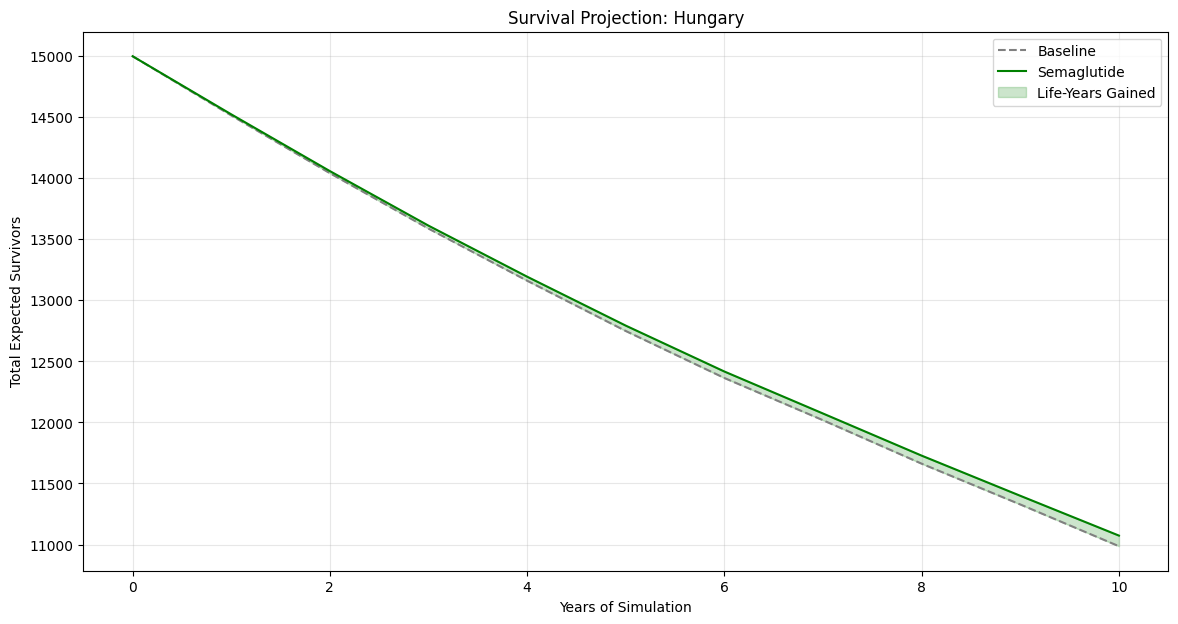

In [27]:
def plot_survival_curves(df, country_name, figsize=(10, 6)):
    # Sum up total survivors per year
    bl_survival = df[bl_cols].sum()
    sg_survival = df[sg_cols].sum()
    years = range(0, 11)
    
    # Create the plot with custom size
    fig, ax = plt.subplots(figsize=figsize)
    
    ax.plot(years, bl_survival, label='Baseline', color='gray', linestyle='--')
    ax.plot(years, sg_survival, label='Semaglutide', color='green')
    ax.fill_between(years, bl_survival, sg_survival, color='green', alpha=0.2, label='Life-Years Gained')
    
    ax.set_title(f"Survival Projection: {country_name}")
    ax.set_xlabel("Years of Simulation")
    ax.set_ylabel("Total Expected Survivors")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

plot_survival_curves(countries_max["HUN"], "Hungary", figsize=(14, 7))

#### plot by age group

In [28]:
countries_max.keys()

dict_keys(['ASM', 'AND', 'ATG', 'AUS', 'AUT', 'BHS', 'BHR', 'BRB', 'BEL', 'BMU', 'BRN', 'CAN', 'CHL', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 'FIN', 'FRA', 'PYF', 'DEU', 'GRC', 'GRL', 'GUY', 'HUN', 'ISL', 'IRL', 'ISR', 'ITA', 'JPN', 'KOR', 'KWT', 'LVA', 'LTU', 'LUX', 'MLT', 'NRU', 'NLD', 'NZL', 'NOR', 'OMN', 'PAN', 'POL', 'PRT', 'PRI', 'QAT', 'ROU', 'SAU', 'SYC', 'SGP', 'SVK', 'SVN', 'ESP', 'KNA', 'SWE', 'CHE', 'TWN', 'TTO', 'ARE', 'GBR', 'USA', 'URY'])

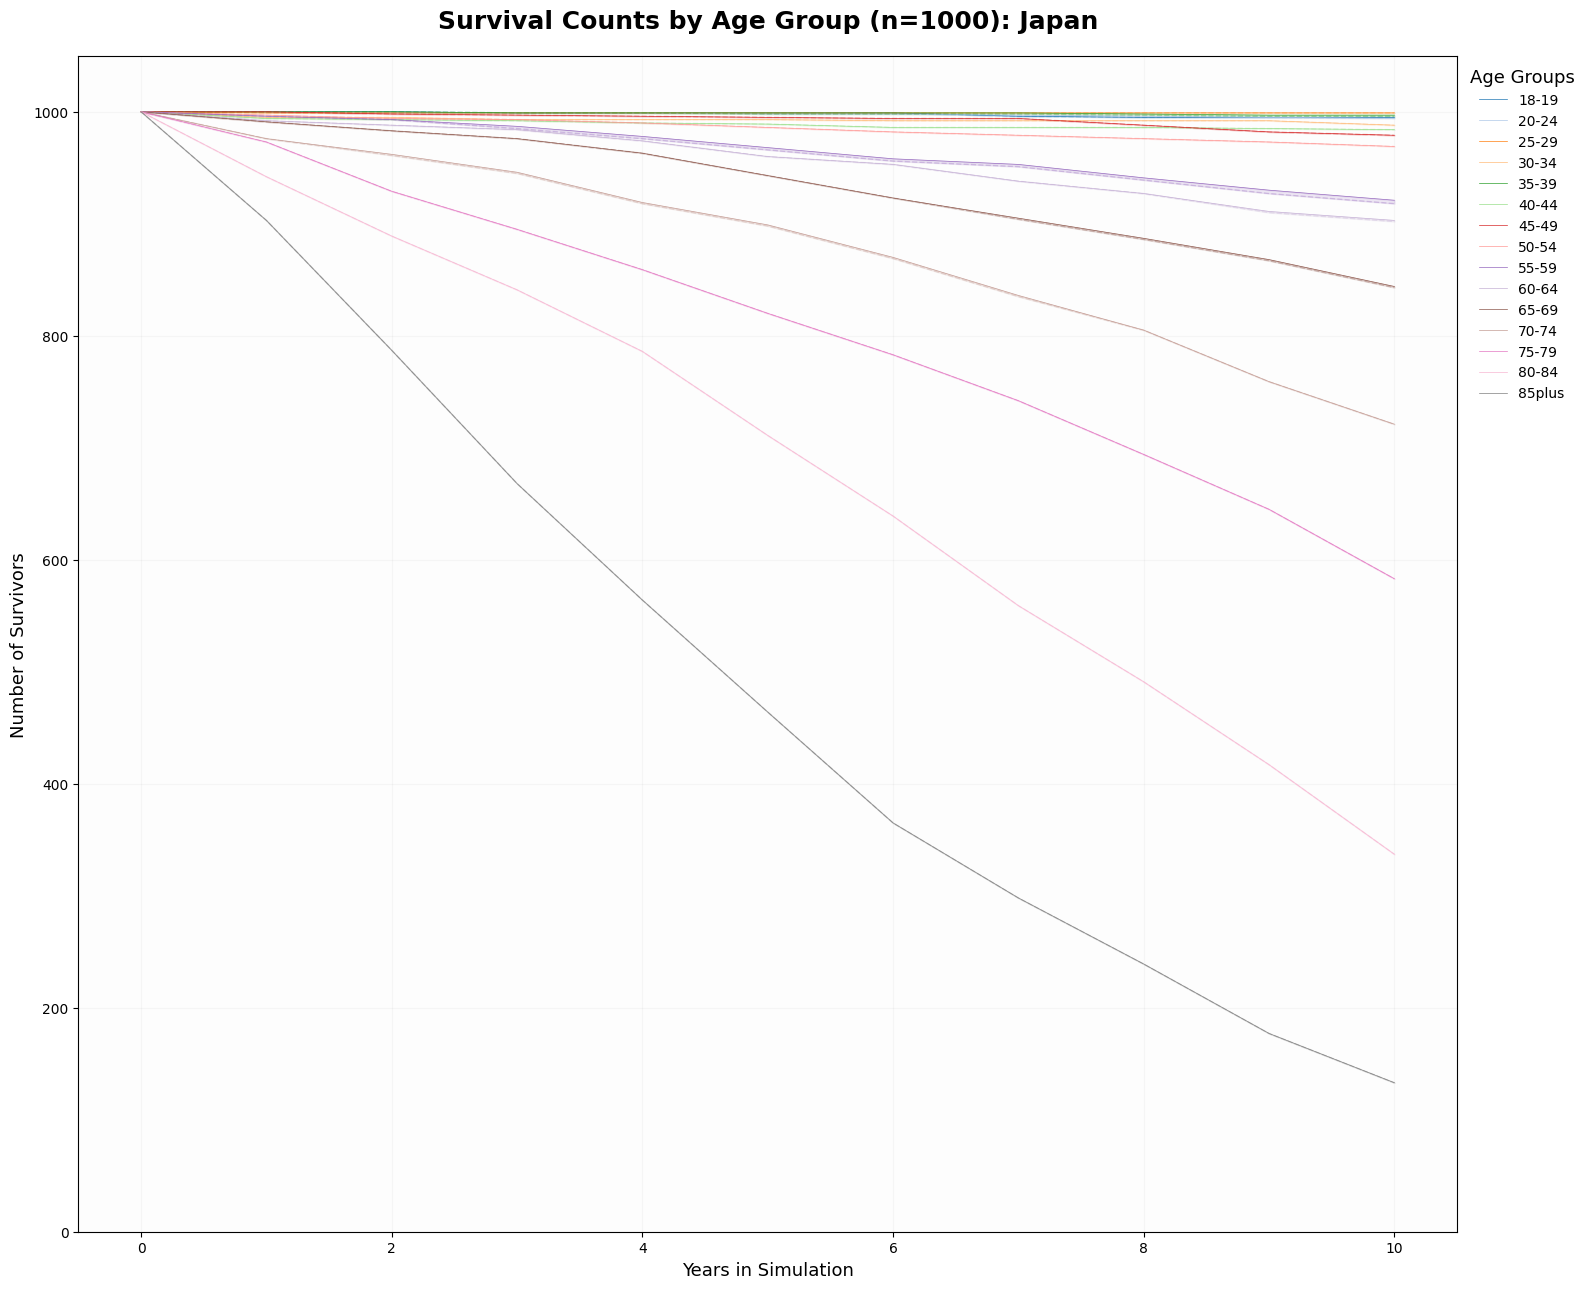

In [29]:
def plot_survival_by_age_group(df, country_name="", figsize=(16, 13)):
    """
    Plots survival curves using distinct qualitative colors for 15 Age_Groups.
    """
    years = range(0, 11)
    fig, ax = plt.subplots(figsize=figsize)
    
    # Sort age groups so the legend is logical
    age_groups = sorted(df['Age_Group'].unique())
    
    # Using 'tab20' which provides 20 distinct categorical colors
    # We pull colors individually to ensure they are distinct and not treated as a spectrum
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i) for i in range(len(age_groups))]

    for i, group in enumerate(age_groups):
        group_df = df[df['Age_Group'] == group]
        
        if group_df.empty:
            continue
            
        # Survivors per year
        bl_survivors = group_df[bl_cols].sum()
        sg_survivors = group_df[sg_cols].sum()
        
        color = colors[i]
        
        # Baseline = Dashed, thinner, and more transparent
        ax.plot(years, bl_survivors, color=color, linestyle='--', linewidth=1, alpha=0.3)
        
        # Treated = Solid, thick, and fully opaque
        ax.plot(years, sg_survivors, color=color, label=f"{group}", linewidth=0.5)
        
        # Fill the "Wedge" area
        ax.fill_between(years, bl_survivors, sg_survivors, color=color, alpha=0.15)

    # Formatting
    ax.set_title(f"Survival Counts by Age Group (n=1000): {country_name}", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Years in Simulation", fontsize=13)
    ax.set_ylabel("Number of Survivors", fontsize=13)
    
    # Keep Y-axis at 0 to 1000 to show the reality of the drop
    ax.set_ylim(0, 1050) 
    
    # Legend - sorted and placed outside to avoid overlapping lines
    ax.legend(title="Age Groups", title_fontsize='13', loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    
    ax.grid(True, linestyle='-', alpha=0.1)
    ax.set_facecolor('#fdfdfd') # Slight off-white background to make colors pop
    
    plt.tight_layout()
    plt.show()

# Execution
plot_survival_by_age_group(countries_max["JPN"], "Japan")

#### person year gained for all countries by age group

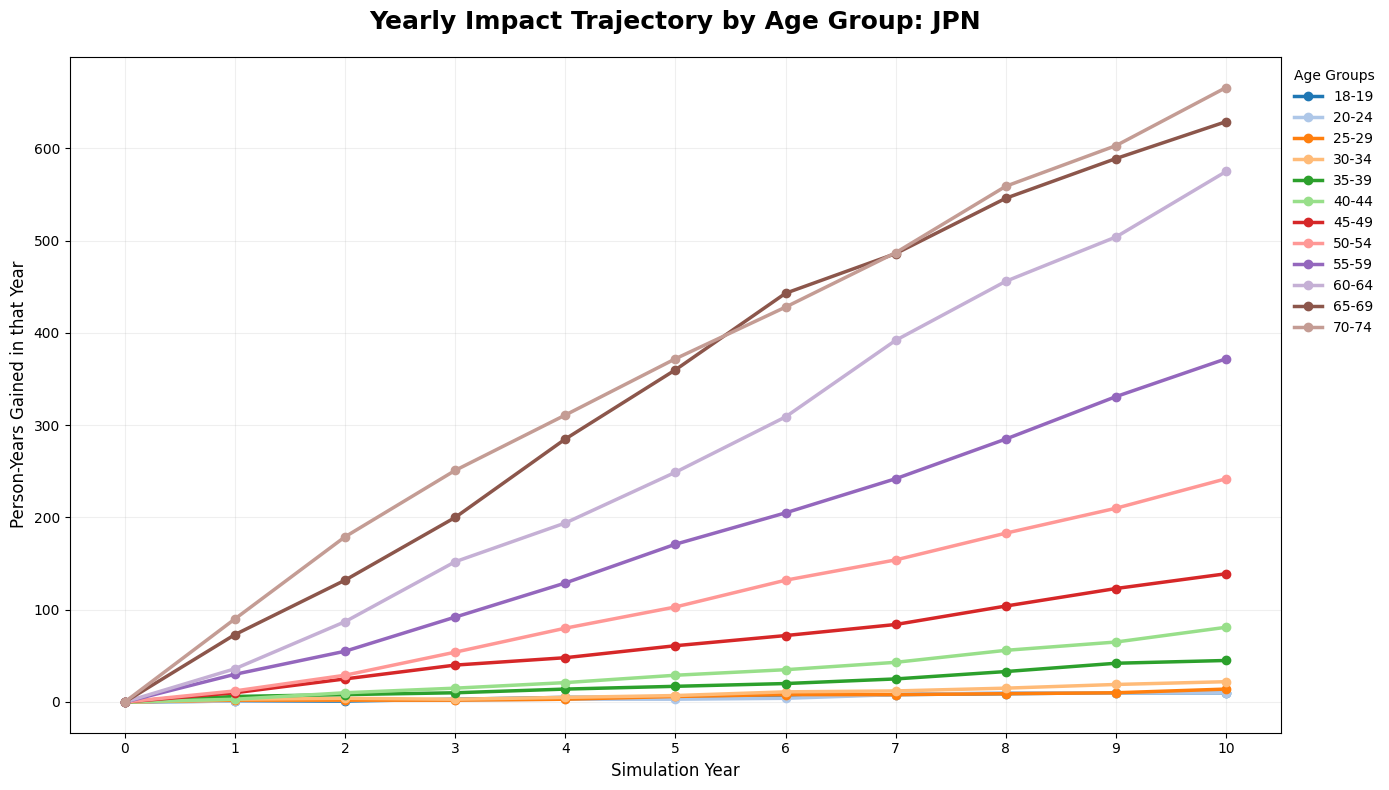

In [30]:
def plot_impact_lines(df, country_name="", figsize=(14, 8)):
    # 1. Prepare Data
    # Group by Age_Group (or 'age' depending on your needs)
    impact_data = remove_zero_diff(df.groupby("Age_Group").sum())[diff_cols]
    plot_data = impact_data.T
    
    # 2. Dynamically get years from column names (e.g., extracts '0' from 'diff_Y0')
    years = [int(col.split('_Y')[1]) for col in plot_data.index]
    
    # 3. Setup Colors
    cmap = plt.get_cmap('tab20')
    colors = [cmap(i % 20) for i in range(len(plot_data.columns))]

    fig, ax = plt.subplots(figsize=figsize)

    for i, column in enumerate(plot_data.columns):
        # Now years and plot_data[column] both have the same length (11)
        ax.plot(years, plot_data[column], label=column, color=colors[i], marker='o', linewidth=2.5)

    ax.set_title(f"Yearly Impact Trajectory by Age Group: {country_name}", fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Simulation Year", fontsize=12)
    ax.set_ylabel("Person-Years Gained in that Year", fontsize=12)
    ax.set_xticks(years)
    
    ax.legend(title="Age Groups", loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

# Usage (ensure 'high' is your filtered dataframe for Max Uptake)
plot_impact_lines(high, "JPN")

#### person year gained for individual countries by age group

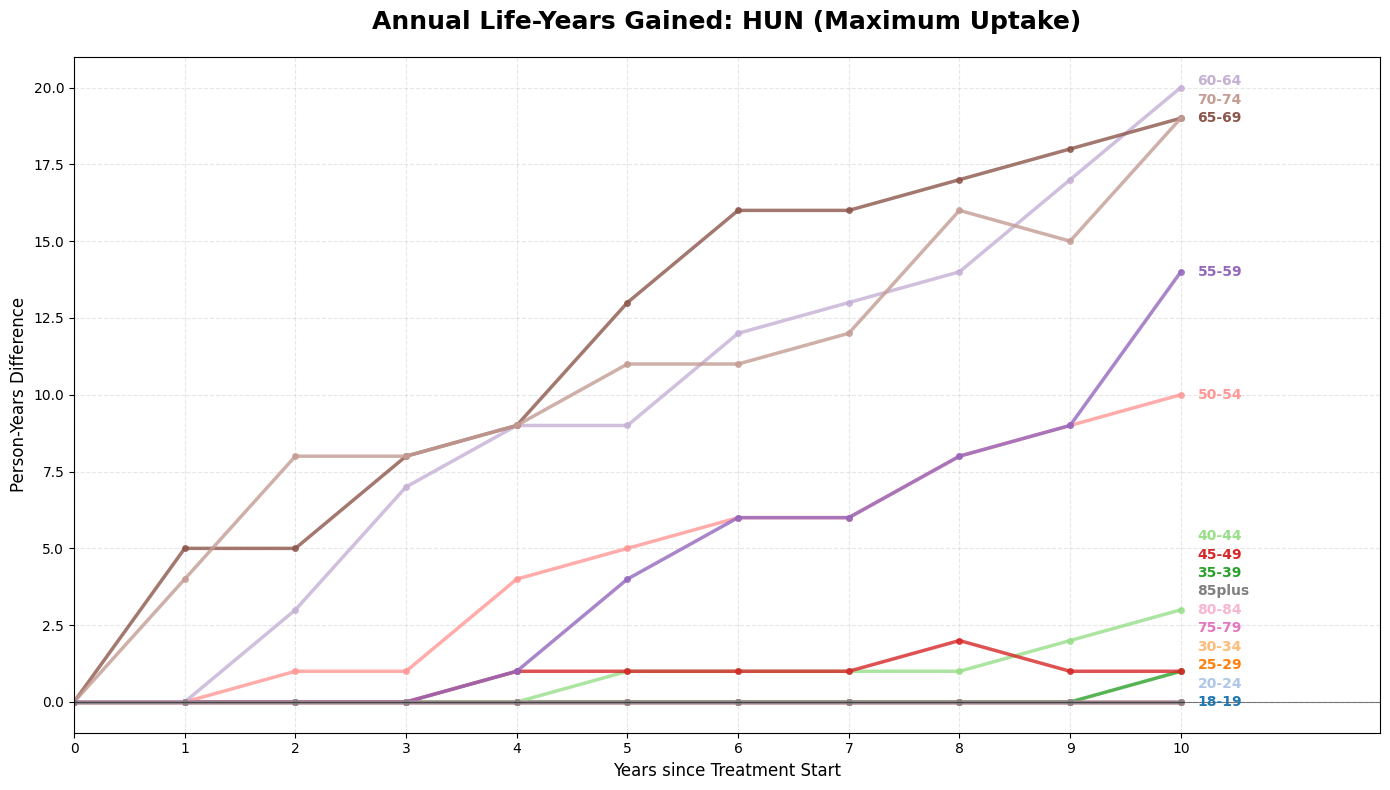

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def plot_country_trajectories(country_dict, iso_code, scenario_label="Max Uptake", figsize=(14, 8)):
    """
    Plots the mortality benefit trajectory with non-overlapping direct labels.
    """
    df = country_dict.get(iso_code)
    if df is None or df.empty:
        print(f"No data found for {iso_code}")
        return

    diff_cols = sorted([col for col in df.columns if "diff_Y" in col], 
                       key=lambda x: int(x.split('_Y')[1]))
    
    plot_data = df.groupby("Age_Group")[diff_cols].sum().T
    years = [int(col.split('_Y')[1]) for col in plot_data.index]

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap('tab20')
    age_groups = plot_data.columns
    
    # Store final positions for label adjustment
    label_positions = []

    for i, group in enumerate(age_groups):
        y_values = plot_data[group]
        line_color = cmap(i % 20)
        
        ax.plot(years, y_values, 
                color=line_color, 
                marker='o', 
                markersize=4,
                linewidth=2.5, 
                alpha=0.8)
        
        # Store the last point for labeling
        label_positions.append({
            'label': group,
            'x': years[-1],
            'y': y_values.iloc[-1],
            'color': line_color
        })

    # --- Collision Avoidance Logic ---
    # Sort labels by their Y position so we can adjust them in order
    label_positions.sort(key=lambda x: x['y'])
    
    # Define a minimum vertical distance (tweak this based on your data scale)
    # 3% of the total Y-range is usually a good starting point for padding
    y_range = max([p['y'] for p in label_positions]) - min([p['y'] for p in label_positions])
    min_dist = y_range * 0.03 if y_range > 0 else 0.5

    for i in range(1, len(label_positions)):
        prev_y = label_positions[i-1]['y']
        curr_y = label_positions[i]['y']
        
        # If too close to the label below, push this one up
        if curr_y - prev_y < min_dist:
            label_positions[i]['y'] = prev_y + min_dist

    # Draw the adjusted labels
    for p in label_positions:
        ax.text(p['x'] + 0.15, p['y'], p['label'], 
                fontsize=10, 
                color=p['color'], 
                va='center', 
                fontweight='bold')

    # Aesthetics
    ax.set_title(f"Annual Life-Years Gained: {iso_code} ({scenario_label})", 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Years since Treatment Start", fontsize=12)
    ax.set_ylabel("Person-Years Difference", fontsize=12)
    
    ax.set_xlim(min(years), max(years) + 1.8) # Extra space for labels
    ax.set_xticks(years)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5) # Baseline reference
    
    plt.tight_layout()
    plt.show()

plot_country_trajectories(countries_max, "HUN", "Maximum Uptake")